**Introduction to the Healthcare Risk Assessment Project**

Healthcare Risk Assessment is a critical tool in preventive medicine, enabling early identification of individuals at risk for specific health conditions. By analyzing patient data, healthcare providers can intervene proactively, personalize treatment plans, and optimize resource allocation. This project leverages a Classification Decision Tree model to predict patient risk levels (e.g., high, medium, low) based on diagnostic features. Decision trees are ideal for this task due to their interpretability, which allows clinicians to understand the reasoning behind each prediction (e.g., "if blood pressure > X and age > Y, then high risk").

The code below demonstrates a simplified workflow for building a healthcare risk assessment model. It includes data preprocessing, model training, evaluation, and visualization of the decision tree. The example uses a synthetic dataset mimicking real-world health metrics like age, blood pressure, and cholesterol levels.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Generate balanced synthetic healthcare dataset
np.random.seed(42)
data_size = 1000

# Simulate features: Age, Blood Pressure, Cholesterol, BMI, Glucose
age = np.random.randint(18, 80, data_size)
blood_pressure = np.random.randint(90, 180, data_size)
cholesterol = np.random.randint(150, 300, data_size)
bmi = np.random.uniform(18.5, 40.0, data_size).round(1)
glucose = np.random.randint(70, 200, data_size)

# Improved risk assignment to ensure all classes are represented
risk = np.zeros(data_size, dtype=int)
for i in range(data_size):
    # Create a more balanced scoring system
    score = 0
    score += 1 if age[i] > 60 else 0
    score += 1 if blood_pressure[i] > 140 else 0
    score += 1 if cholesterol[i] > 240 else 0
    score += 1 if bmi[i] > 30 else 0
    score += 1 if glucose[i] > 140 else 0

    # Ensure balanced distribution across three classes
    if score <= 1:
        risk[i] = 0  # Low risk
    elif score <= 3:
        risk[i] = 1  # Medium risk
    else:
        risk[i] = 2  # High risk

# Create DataFrame
df = pd.DataFrame({
    'Age': age,
    'BloodPressure': blood_pressure,
    'Cholesterol': cholesterol,
    'BMI': bmi,
    'Glucose': glucose,
    'Risk': risk
})

# Ensure Risk column is integer type
df['Risk'] = df['Risk'].astype(int)

# Display dataset info
print("Dataset Head:")
print(df.head())
print("\nRisk Distribution:")
risk_counts = df['Risk'].value_counts().sort_index()
print(risk_counts)

Dataset Head:
   Age  BloodPressure  Cholesterol   BMI  Glucose  Risk
0   56            100          155  29.2      122     0
1   69            174          296  25.8      103     1
2   46            115          280  37.3      136     1
3   32            152          150  30.2       96     1
4   60            178          207  34.8       79     1

Risk Distribution:
Risk
0    299
1    596
2    105
Name: count, dtype: int64


In [2]:
# Check if we have all three classes
if len(risk_counts) < 3:
    print(f"Warning: Only {len(risk_counts)} class(es) present. Adjusting data generation...")
    # Force inclusion of all classes by manually adding examples
    missing_classes = set([0, 1, 2]) - set(risk_counts.index)
    for missing_class in missing_classes:
        if missing_class == 0:  # Low risk
            new_row = {'Age': 30, 'BloodPressure': 100, 'Cholesterol': 160,
                      'BMI': 22.0, 'Glucose': 80, 'Risk': 0}
        elif missing_class == 1:  # Medium risk
            new_row = {'Age': 55, 'BloodPressure': 130, 'Cholesterol': 220,
                      'BMI': 28.0, 'Glucose': 110, 'Risk': 1}
        else:  # High risk
            new_row = {'Age': 70, 'BloodPressure': 160, 'Cholesterol': 280,
                      'BMI': 35.0, 'Glucose': 180, 'Risk': 2}
        df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)

    # Re-ensure Risk column is integer after adding new rows
    df['Risk'] = df['Risk'].astype(int)

print("\nAdjusted Risk Distribution:")
print(df['Risk'].value_counts().sort_index())

# Split data into features (X) and target (y)
X = df.drop('Risk', axis=1)
y = df['Risk']

# Split into training (80%) and testing (20%) sets with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize and train Decision Tree classifier
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    min_samples_split=20,  # Prevent overfitting
    random_state=42
)
dt_model.fit(X_train, y_train)


Adjusted Risk Distribution:
Risk
0    299
1    596
2    105
Name: count, dtype: int64


DecisionTreeClassifier(max_depth=4, min_samples_split=20, random_state=42)


Model Accuracy: 0.80

Classification Report:
              precision    recall  f1-score   support

         Low       0.71      0.97      0.82        60
      Medium       0.85      0.79      0.82       119
        High       0.88      0.33      0.48        21

    accuracy                           0.80       200
   macro avg       0.81      0.70      0.71       200
weighted avg       0.81      0.80      0.78       200

Confusion Matrix:
[[58  2  0]
 [24 94  1]
 [ 0 14  7]]


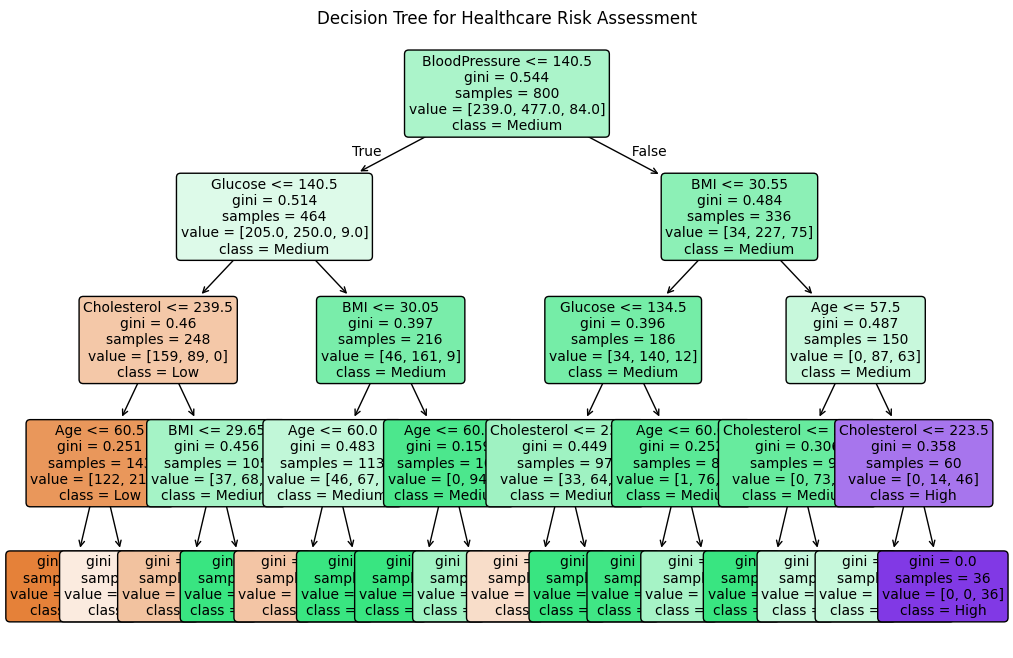

In [3]:
# Predict on test set
y_pred = dt_model.predict(X_test)

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.2f}")

# Get the actual classes present in the test set and ensure they are integers
unique_classes = np.unique(np.concatenate([y_test, y_pred]))
class_names = ['Low', 'Medium', 'High']

# Convert unique_classes to integers and create present_class_names
present_class_names = [class_names[int(i)] for i in unique_classes]

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=present_class_names))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Visualize the decision tree with only present classes
plt.figure(figsize=(12, 8))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=class_names,  # Use all class names for the tree visualization
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree for Healthcare Risk Assessment")
plt.show()

In [4]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)

# Example predictions for new patients
new_patients = [
    [25, 110, 180, 22.0, 90],   # Young, healthy (Low risk)
    [45, 135, 230, 27.5, 125],  # Middle-aged, some risk factors (Medium risk)
    [65, 155, 270, 33.0, 160]   # Older, multiple risk factors (High risk)
]

risk_levels = {0: 'Low', 1: 'Medium', 2: 'High'}
print("\nNew Patient Risk Predictions:")
for i, patient in enumerate(new_patients):
    prediction = dt_model.predict([patient])
    probability = dt_model.predict_proba([patient])
    pred_class = int(prediction[0])  # Ensure integer for indexing
    print(f"Patient {i+1}: {risk_levels[pred_class]} risk")
    print(f"Probabilities: Low: {probability[0][0]:.3f}, Medium: {probability[0][1]:.3f}, High: {probability[0][2]:.3f}")
    print("-" * 50)


Feature Importance:
         feature  importance
0            Age    0.256697
2    Cholesterol    0.239247
3            BMI    0.200919
4        Glucose    0.173902
1  BloodPressure    0.129234

New Patient Risk Predictions:
Patient 1: Low risk
Probabilities: Low: 1.000, Medium: 0.000, High: 0.000
--------------------------------------------------
Patient 2: Low risk
Probabilities: Low: 1.000, Medium: 0.000, High: 0.000
--------------------------------------------------
Patient 3: High risk
Probabilities: Low: 0.000, Medium: 0.000, High: 1.000
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local

**Key Steps Explained:**

* Synthetic Data Generation: Creates a dataset with health metrics and heuristic-based risk labels.

* Data Preprocessing: Splits data into features (X) and target (y), then into training/test sets.

* Model Training: Uses a Decision Tree with a maximum depth of 4 to balance accuracy and interpretability.

* Evaluation: Metrics like accuracy, classification report, and confusion matrix assess performance.

* Visualization: The decision tree plot shows how features split the data into risk categories.

* Prediction: Demonstrates risk assessment for a new patient.